# Render Results and Performance Analysis

This notebook analyzes parallel rendering results, with emphasis on success rate, skipped labels, failure reasons, per-scene pass/fail distribution, path length and timing, and retry behavior.


## Setup and configuration

Load dependencies, configure paths, and set display defaults. Update the paths if you want to analyze a different run.


In [1]:
from __future__ import annotations

import json
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

REPORT_PATH = Path("parallel_render_report_0500fpv.json")
ERROR_LOG_PATH = Path("0500_fpv.log")
METRICS_ROOT = Path("analysis/fpv_metrics")

REPORT_PATH


PosixPath('parallel_render_report_0500fpv.json')

## Load report and normalize tables

Parse the report JSON into dataframes for jobs, skipped labels, and planned path assignments.


In [2]:
report = json.loads(REPORT_PATH.read_text(encoding="utf-8"))

jobs_df = pd.DataFrame(report.get("jobs", []))
skipped_df = pd.DataFrame(report.get("skipped_labels", []))
path_assignments_df = pd.DataFrame(report.get("path_assignments", []))

if not jobs_df.empty:
    jobs_df["status"] = jobs_df["status"].fillna("unknown")
    jobs_df["label_count"] = jobs_df["labels"].apply(lambda x: len(x) if isinstance(x, list) else 0)
    jobs_df["duration_sec"] = pd.to_numeric(jobs_df["duration_sec"], errors="coerce")

jobs_df.head()


,scene,actor_id,labels,cmd,log,status,returncode,pid,duration_sec,job_name,metrics_path,label_count
0,0001_839920,fpv,"[100, 108, 111, 112, 113, 114, 115, 116, 118, ...","[/home/dongjk/.conda/envs/cuda121/bin/python, ...",parallel_render_logs/0001_0001_839920_fpv_pid3...,success,0,3911519,616.053257,0001_0001_839920_fpv,/home/dongjk/project_files/NavDP_Jiankun_ver/n...,56
1,0002_839955,fpv,"[100, 102, 105, 106, 127, 128, 129, 130, 131, ...","[/home/dongjk/.conda/envs/cuda121/bin/python, ...",parallel_render_logs/0002_0002_839955_fpv_pid3...,success,0,3911524,306.159661,0002_0002_839955_fpv,/home/dongjk/project_files/NavDP_Jiankun_ver/n...,46
2,0003_839989,fpv,"[100, 101, 102, 103, 104, 105, 106, 107, 108, ...","[/home/dongjk/.conda/envs/cuda121/bin/python, ...",parallel_render_logs/0003_0003_839989_fpv_pid3...,success,0,3911526,1994.962274,0003_0003_839989_fpv,/home/dongjk/project_files/NavDP_Jiankun_ver/n...,168
3,0004_840011,fpv,"[100, 103, 104, 105, 106, 107, 108, 109, 111, ...","[/home/dongjk/.conda/envs/cuda121/bin/python, ...",parallel_render_logs/0004_0004_840011_fpv_pid3...,success,0,3911527,2818.890322,0004_0004_840011_fpv,/home/dongjk/project_files/NavDP_Jiankun_ver/n...,205
4,0005_840050,fpv,"[1000, 1002, 1003, 1010, 1018, 1022, 1028, 103...","[/home/dongjk/.conda/envs/cuda121/bin/python, ...",parallel_render_logs/0005_0005_840050_fpv_pid3...,success,0,3911531,288.899781,0005_0005_840050_fpv,/home/dongjk/project_files/NavDP_Jiankun_ver/n...,27


## Load per-path metrics (optional)

Each job can produce a metrics JSON. Load them for per-path timing, FPS, and status analysis.


In [3]:
def load_metrics(metrics_paths):
    path_rows = []
    status_rows = []
    missing = []

    for metrics_path in metrics_paths:
        if not metrics_path:
            continue
        path = Path(metrics_path)
        if not path.exists():
            missing.append(str(path))
            continue
        try:
            data = json.loads(path.read_text(encoding="utf-8"))
        except json.JSONDecodeError:
            missing.append(str(path))
            continue

        job_name = data.get("job_name")
        actor_id = data.get("actor_id")

        for row in data.get("paths", []):
            item = dict(row)
            item["job_name"] = job_name
            item["actor_id"] = actor_id
            path_rows.append(item)

        for row in data.get("path_statuses", []):
            item = dict(row)
            item["job_name"] = job_name
            item["actor_id"] = actor_id
            status_rows.append(item)

    return pd.DataFrame(path_rows), pd.DataFrame(status_rows), missing

metrics_paths = []
if not jobs_df.empty:
    metrics_paths = jobs_df["metrics_path"].dropna().unique().tolist()

metrics_paths_df, path_status_df, missing_metrics = load_metrics(metrics_paths)

if not metrics_paths_df.empty:
    metrics_paths_df["duration_sec"] = pd.to_numeric(metrics_paths_df["duration_sec"], errors="coerce")
    metrics_paths_df["frames"] = pd.to_numeric(metrics_paths_df["frames"], errors="coerce")
    metrics_paths_df["frames_per_sec"] = pd.to_numeric(metrics_paths_df["frames_per_sec"], errors="coerce")
    metrics_paths_df["vram_peak_bytes"] = pd.to_numeric(metrics_paths_df["vram_peak_bytes"], errors="coerce")

if not path_status_df.empty:
    path_status_df["status"] = pd.to_numeric(path_status_df["status"], errors="coerce")
    path_status_df["status_label"] = path_status_df["status"].map({1: "success", 0: "failed"}).fillna("unknown")

len(metrics_paths_df), len(path_status_df), len(missing_metrics)


(162954, 28536, 94)

## High-level summary

Compute success rate, executed path counts, skipped labels, and coverage gaps.


,metric,value
0,total_jobs,968.00000
1,executed_jobs,968.00000
2,successful_jobs,873.00000
3,failed_jobs,95.00000
4,job_success_rate,0.90186
5,planned_paths,178628.00000
6,skipped_labels,32418.00000
7,executed_labels,178628.00000
8,success_labels,162954.00000
9,failed_labels,15674.00000


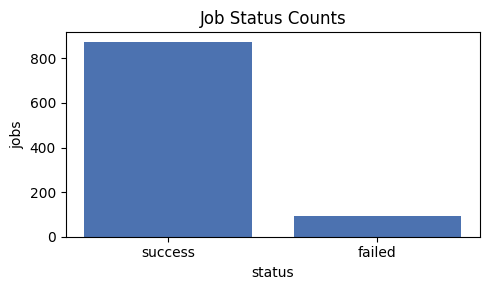

In [4]:
total_jobs = report.get("total_jobs", len(jobs_df))
executed_jobs = report.get("executed_jobs", len(jobs_df))
successful_jobs = report.get("successful_jobs", int((jobs_df["status"] == "success").sum()))
failed_jobs = report.get("failed_jobs", int((jobs_df["status"] != "success").sum()))
job_success_rate = successful_jobs / executed_jobs if executed_jobs else np.nan

planned_paths = len(path_assignments_df)
skipped_labels = len(skipped_df)
executed_labels = int(jobs_df["label_count"].sum()) if not jobs_df.empty else 0
failed_labels = int(jobs_df.loc[jobs_df["status"] != "success", "label_count"].sum()) if not jobs_df.empty else 0
success_labels = int(jobs_df.loc[jobs_df["status"] == "success", "label_count"].sum()) if not jobs_df.empty else 0

paths_generated = len(metrics_paths_df)
paths_with_status = len(path_status_df)
paths_success = int((path_status_df["status_label"] == "success").sum()) if not path_status_df.empty else 0
paths_failed = int((path_status_df["status_label"] == "failed").sum()) if not path_status_df.empty else 0

coverage_gap = planned_paths - skipped_labels - executed_labels

summary_rows = [
    ("total_jobs", total_jobs),
    ("executed_jobs", executed_jobs),
    ("successful_jobs", successful_jobs),
    ("failed_jobs", failed_jobs),
    ("job_success_rate", job_success_rate),
    ("planned_paths", planned_paths),
    ("skipped_labels", skipped_labels),
    ("executed_labels", executed_labels),
    ("success_labels", success_labels),
    ("failed_labels", failed_labels),
    ("coverage_gap_planned_minus_skipped_minus_executed", coverage_gap),
    ("paths_generated_in_metrics", paths_generated),
    ("paths_with_status", paths_with_status),
    ("paths_success", paths_success),
    ("paths_failed", paths_failed),
]
summary_df = pd.DataFrame(summary_rows, columns=["metric", "value"])

display(summary_df)

status_counts = jobs_df["status"].value_counts() if not jobs_df.empty else pd.Series(dtype=int)

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(status_counts.index, status_counts.values, color="#4C72B0")
ax.set_title("Job Status Counts")
ax.set_ylabel("jobs")
ax.set_xlabel("status")
plt.tight_layout()


## Job-level performance

Analyze job durations and compare runtime distribution between successful and failed jobs.


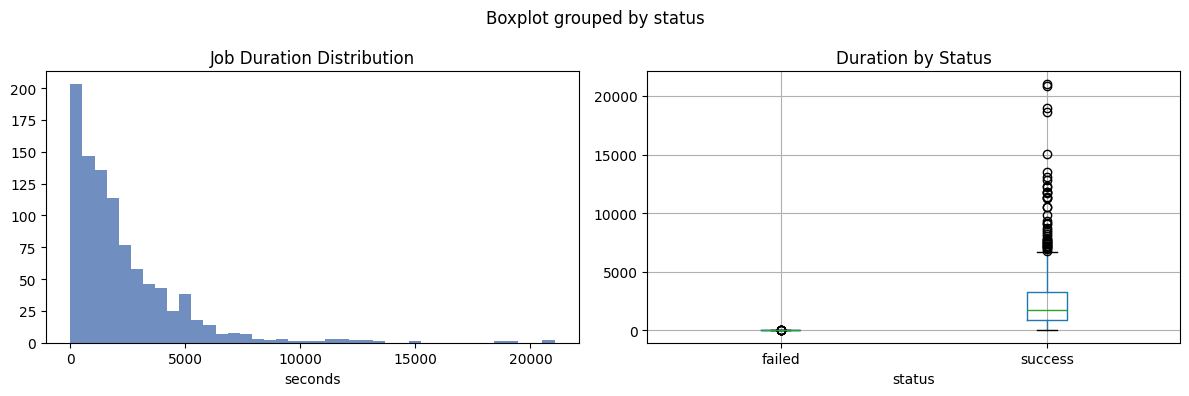

In [5]:
def histplot(ax, data, bins, title, xlabel):
    series = pd.Series(data).dropna()
    if series.empty:
        ax.text(0.5, 0.5, "no data", ha="center", va="center")
        ax.set_axis_off()
        return
    if sns:
        sns.histplot(series, bins=bins, ax=ax, color="#4C72B0")
    else:
        ax.hist(series, bins=bins, color="#4C72B0", alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
duration_series = jobs_df["duration_sec"] if "duration_sec" in jobs_df else []
histplot(axes[0], duration_series, 40, "Job Duration Distribution", "seconds")

if not jobs_df.empty and {"status", "duration_sec"}.issubset(jobs_df.columns):
    if sns:
        sns.boxplot(data=jobs_df, x="status", y="duration_sec", ax=axes[1])
    else:
        jobs_df.boxplot(column="duration_sec", by="status", ax=axes[1])
        axes[1].set_title("Duration by Status")
        axes[1].set_xlabel("status")
else:
    axes[1].text(0.5, 0.5, "no data", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()


## Path-level performance and lengths

Inspect planned path length, estimated frames, per-path render time, FPS, and correlation with path length.


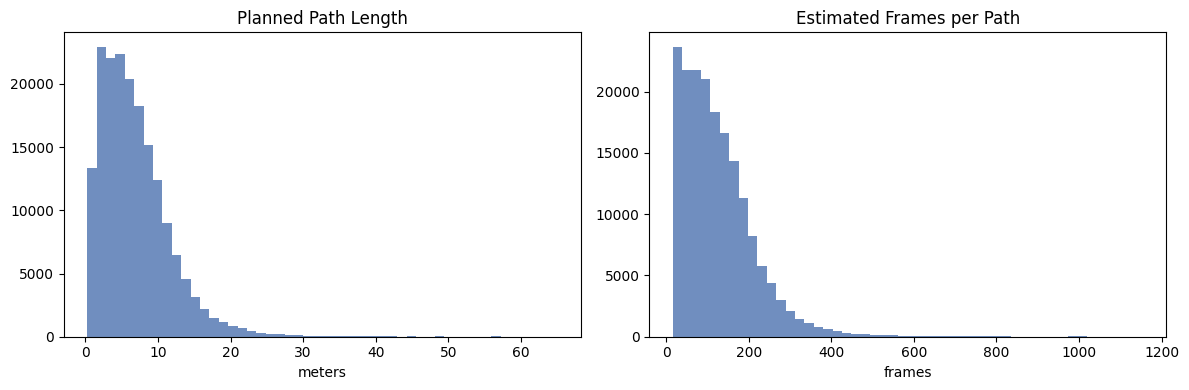

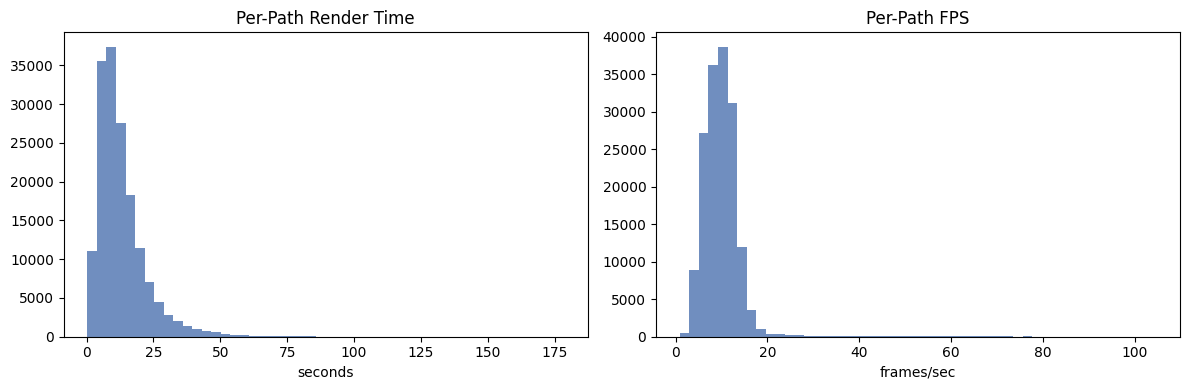

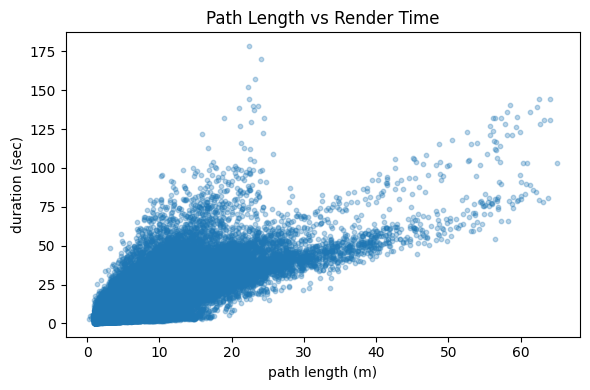

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if not path_assignments_df.empty:
    histplot(axes[0], path_assignments_df["path_length_m"], 50, "Planned Path Length", "meters")
    histplot(axes[1], path_assignments_df["estimated_frames"], 50, "Estimated Frames per Path", "frames")
else:
    axes[0].text(0.5, 0.5, "no data", ha="center", va="center")
    axes[0].set_axis_off()
    axes[1].text(0.5, 0.5, "no data", ha="center", va="center")
    axes[1].set_axis_off()
plt.tight_layout()

if not metrics_paths_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    histplot(axes[0], metrics_paths_df["duration_sec"], 50, "Per-Path Render Time", "seconds")
    histplot(axes[1], metrics_paths_df["frames_per_sec"], 50, "Per-Path FPS", "frames/sec")
    plt.tight_layout()

if not metrics_paths_df.empty and not path_assignments_df.empty:
    assignments = path_assignments_df.rename(columns={"scene": "scene_id", "label": "label_id"})
    assignments["label_id"] = assignments["label_id"].astype(str)
    metrics_paths_df["label_id"] = metrics_paths_df["label_id"].astype(str)

    merged = metrics_paths_df.merge(
        assignments[["scene_id", "label_id", "path_length_m", "estimated_frames"]],
        on=["scene_id", "label_id"],
        how="left",
    )
    merged = merged.dropna(subset=["path_length_m", "duration_sec"])

    if not merged.empty:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.scatter(merged["path_length_m"], merged["duration_sec"], s=10, alpha=0.3)
        ax.set_title("Path Length vs Render Time")
        ax.set_xlabel("path length (m)")
        ax.set_ylabel("duration (sec)")
        plt.tight_layout()


## Scene-level pass/fail/skip distribution

Aggregate label counts per scene to see where failures and skips cluster.


,scene,jobs,success_jobs,failed_jobs,executed_labels,success_labels,failed_labels,avg_job_duration,skipped_labels,planned_paths,fail_rate,skip_rate
418,0440_840286,1,0,1,500,0,500,8.240375,35,500,1.0,0.070000
518,0543_840901,1,0,1,405,0,405,13.777087,34,405,1.0,0.083951
578,0603_841172,1,0,1,323,0,323,10.076288,30,323,1.0,0.092879
411,0433_839891,1,0,1,314,0,314,14.665768,31,314,1.0,0.098726
576,0601_841162,1,0,1,311,0,311,9.841341,49,311,1.0,0.157556
415,0437_840213,1,0,1,305,0,305,14.392710,47,305,1.0,0.154098
644,0675_841498,1,0,1,291,0,291,20.012193,71,291,1.0,0.243986
413,0435_839884,1,0,1,287,0,287,12.424684,35,287,1.0,0.121951
467,0489_840958,1,0,1,277,0,277,17.109146,32,277,1.0,0.115523
419,0441_840314,1,0,1,275,0,275,15.516840,34,275,1.0,0.123636


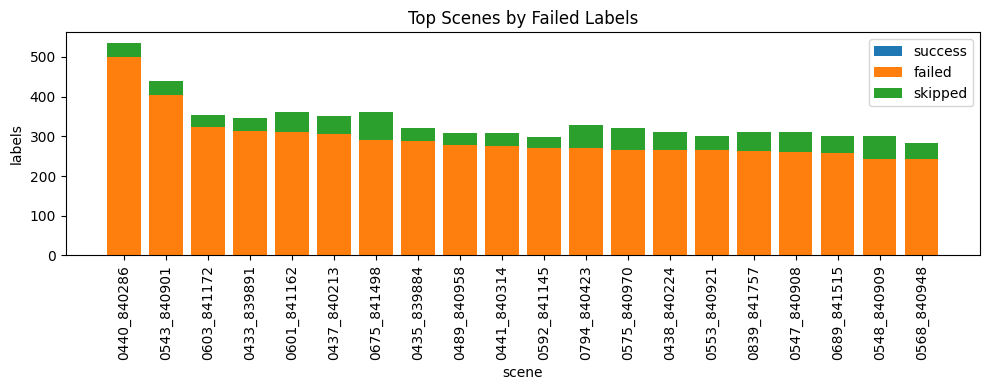

In [7]:
scene_stats = pd.DataFrame()

if not jobs_df.empty:
    temp = jobs_df.copy()
    temp["success_labels"] = np.where(temp["status"] == "success", temp["label_count"], 0)
    temp["failed_labels"] = np.where(temp["status"] != "success", temp["label_count"], 0)

    scene_stats = temp.groupby("scene", as_index=False).agg(
        jobs=("job_name", "count"),
        success_jobs=("status", lambda s: (s == "success").sum()),
        failed_jobs=("status", lambda s: (s != "success").sum()),
        executed_labels=("label_count", "sum"),
        success_labels=("success_labels", "sum"),
        failed_labels=("failed_labels", "sum"),
        avg_job_duration=("duration_sec", "mean"),
    )

    if not skipped_df.empty:
        skipped_scene = skipped_df.groupby("scene").size().rename("skipped_labels")
        scene_stats = scene_stats.merge(skipped_scene, on="scene", how="left")
    else:
        scene_stats["skipped_labels"] = 0

    if not path_assignments_df.empty:
        planned_scene = path_assignments_df.groupby("scene").size().rename("planned_paths")
        scene_stats = scene_stats.merge(planned_scene, on="scene", how="left")
    else:
        scene_stats["planned_paths"] = 0

    scene_stats["skipped_labels"] = scene_stats["skipped_labels"].fillna(0).astype(int)
    scene_stats["planned_paths"] = scene_stats["planned_paths"].fillna(0).astype(int)
    scene_stats["fail_rate"] = scene_stats["failed_labels"] / (scene_stats["success_labels"] + scene_stats["failed_labels"]).replace(0, np.nan)
    scene_stats["skip_rate"] = scene_stats["skipped_labels"] / scene_stats["planned_paths"].replace(0, np.nan)

    display(scene_stats.sort_values("failed_labels", ascending=False).head(10))

    top = scene_stats.sort_values("failed_labels", ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(top["scene"], top["success_labels"], label="success")
    ax.bar(top["scene"], top["failed_labels"], bottom=top["success_labels"], label="failed")
    ax.bar(
        top["scene"],
        top["skipped_labels"],
        bottom=top["success_labels"] + top["failed_labels"],
        label="skipped",
    )
    ax.set_title("Top Scenes by Failed Labels")
    ax.set_ylabel("labels")
    ax.set_xlabel("scene")
    ax.tick_params(axis="x", rotation=90)
    ax.legend()
    plt.tight_layout()
else:
    print("No job data available for scene-level analysis.")


## Skip and failure reasons

Analyze why labels were skipped and summarize exception types from the error log.


reason_category
prepare_failed            32417
missing_meta_or_labels        1
Name: count, dtype: int64

,failed_events,unique_failed_scenes,total_failed_labels
0,95,95,15674


scene
0270_840784    1
0422_840015    1
0423_840010    1
0424_839994    1
0426_839927    1
0427_839934    1
0428_839921    1
0429_839912    1
0430_839908    1
0433_839891    1
Name: count, dtype: int64

,exception_type,count
0,CUDA_OOM,84
1,RuntimeError,10


,exception_detail,count
0,RuntimeError: CUDA error: out of memory,84
1,RuntimeError: CUDA device required for renderi...,9
2,RuntimeError: CUDA error: CUDA-capable device(...,1


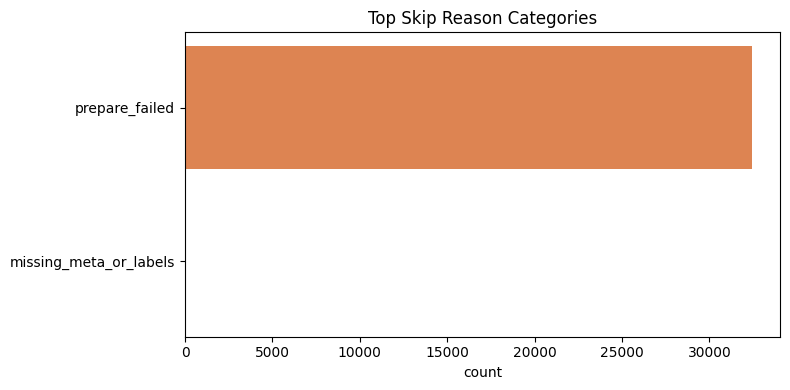

In [8]:
if not skipped_df.empty:
    skipped_df["reason"] = skipped_df["reason"].fillna("unknown")
    skipped_df["reason_category"] = skipped_df["reason"].str.split(":", n=1).str[0]

    reason_counts = skipped_df["reason_category"].value_counts()
    display(reason_counts.head(10))

    fig, ax = plt.subplots(figsize=(8, 4))
    top = reason_counts.head(10)
    ax.barh(top.index[::-1], top.values[::-1], color="#DD8452")
    ax.set_title("Top Skip Reason Categories")
    ax.set_xlabel("count")
    plt.tight_layout()


def parse_error_log(log_path: Path):
    failed_events = []
    retry_events = []
    exception_counts = Counter()
    exception_detail_counts = Counter()

    if not log_path.exists():
        return failed_events, retry_events, exception_counts, exception_detail_counts

    failed_re = re.compile(r"^\[FAILED\]\s+scene=(\S+)\s+actor=(\S+)\s+labels=(\d+)\s+returncode=(\d+)")
    retry_re = re.compile(r"^\[RETRY\]\[(.*?)\]\s+scene=(\S+)\s+actor=(\S+)\s+attempt=(\d+)")
    exc_re = re.compile(r"^([A-Za-z_]+Error|Exception):\s*(.*)$")

    for line in log_path.read_text(errors="ignore").splitlines():
        line = line.strip()
        match = failed_re.match(line)
        if match:
            failed_events.append(
                {
                    "scene": match.group(1),
                    "actor": match.group(2),
                    "labels": int(match.group(3)),
                    "returncode": int(match.group(4)),
                }
            )
            continue

        match = retry_re.match(line)
        if match:
            retry_events.append(
                {
                    "reason": match.group(1),
                    "scene": match.group(2),
                    "actor": match.group(3),
                    "attempt": int(match.group(4)),
                }
            )
            continue

        match = exc_re.match(line)
        if match:
            kind, detail = match.group(1), match.group(2)
            key = f"{kind}: {detail}".strip()
            if "CUDA error: out of memory" in line:
                exception_counts["CUDA_OOM"] += 1
            else:
                exception_counts[kind] += 1
            exception_detail_counts[key] += 1

    return failed_events, retry_events, exception_counts, exception_detail_counts

failed_events, retry_events, exception_counts, exception_detail_counts = parse_error_log(ERROR_LOG_PATH)
failed_df = pd.DataFrame(failed_events)

if not failed_df.empty:
    failed_summary = pd.DataFrame(
        {
            "failed_events": [len(failed_df)],
            "unique_failed_scenes": [failed_df["scene"].nunique()],
            "total_failed_labels": [failed_df["labels"].sum()],
        }
    )
    display(failed_summary)
    display(failed_df["scene"].value_counts().head(10))

if exception_counts:
    display(pd.DataFrame(exception_counts.most_common(10), columns=["exception_type", "count"]))
    display(pd.DataFrame(exception_detail_counts.most_common(10), columns=["exception_detail", "count"]))


## Retry analysis

Count retry events and show the most common retry reasons and scenes.


,total_retry_events,unique_retry_scenes,max_attempt_overall
0,97,94,2


reason
CUDA_OOM    97
Name: count, dtype: int64

scene
0587_841006    2
0494_840902    2
0599_841166    2
0126_840028    1
0036_839878    1
0125_840026    1
0271_840786    1
0272_840787    1
0273_840788    1
0275_840778    1
Name: attempt, dtype: int64

,failed_scenes_with_retries
0,0


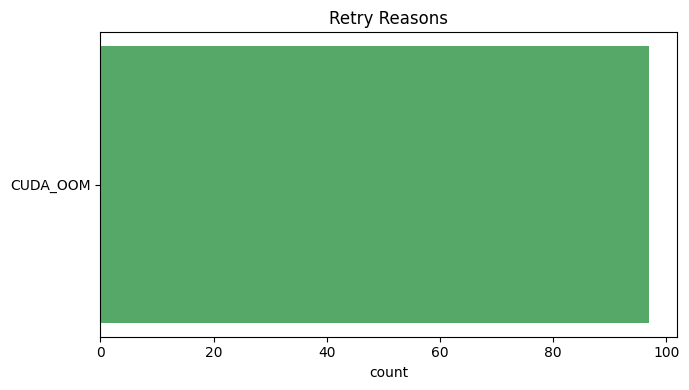

In [9]:
retry_df = pd.DataFrame(retry_events)

if not retry_df.empty:
    retry_summary = pd.DataFrame(
        {
            "total_retry_events": [len(retry_df)],
            "unique_retry_scenes": [retry_df["scene"].nunique()],
            "max_attempt_overall": [retry_df["attempt"].max()],
        }
    )
    display(retry_summary)

    retry_reason_counts = retry_df["reason"].value_counts()
    display(retry_reason_counts)

    fig, ax = plt.subplots(figsize=(7, 4))
    top = retry_reason_counts.head(10)
    ax.barh(top.index[::-1], top.values[::-1], color="#55A868")
    ax.set_title("Retry Reasons")
    ax.set_xlabel("count")
    plt.tight_layout()

    retry_attempts = retry_df.groupby("scene")["attempt"].max().sort_values(ascending=False).head(10)
    display(retry_attempts)

    if not failed_df.empty:
        failed_retry_scenes = sorted(set(failed_df["scene"]) & set(retry_df["scene"]))
        display(pd.DataFrame({"failed_scenes_with_retries": [len(failed_retry_scenes)]}))
else:
    print("No retry events found in error log.")


## Outliers and problem-focused tables

Highlight slow jobs, slow paths, scenes with high fail or skip rates, and unusually long planned paths.


In [10]:
if not jobs_df.empty:
    slow_jobs = jobs_df.sort_values("duration_sec", ascending=False).head(10)[
        ["scene", "job_name", "status", "label_count", "duration_sec", "log"]
    ]
    display(slow_jobs)

if not metrics_paths_df.empty:
    slow_paths = metrics_paths_df.sort_values("duration_sec", ascending=False).head(10)[
        ["scene_id", "label_id", "duration_sec", "frames", "frames_per_sec", "job_name"]
    ]
    display(slow_paths)

if not path_assignments_df.empty:
    long_paths = path_assignments_df.sort_values("path_length_m", ascending=False).head(10)
    display(long_paths[["scene", "label", "path_length_m", "estimated_frames"]])

if not scene_stats.empty:
    active = scene_stats[(scene_stats["success_labels"] + scene_stats["failed_labels"]) >= 20].copy()
    worst_fail_rate = active.sort_values("fail_rate", ascending=False).head(10)[
        ["scene", "fail_rate", "failed_labels", "success_labels", "skipped_labels", "planned_paths"]
    ]
    display(worst_fail_rate)

    worst_skip_rate = scene_stats.sort_values("skip_rate", ascending=False).head(10)[
        ["scene", "skip_rate", "skipped_labels", "planned_paths", "failed_labels", "success_labels"]
    ]
    display(worst_skip_rate)


,scene,job_name,status,label_count,duration_sec,log
390,0405_840145,0391_0405_840145_fpv,success,374,21047.358288,parallel_render_logs/0391_0405_840145_fpv_pid4...
172,0184_840116,0173_0184_840116_fpv,success,500,20863.176717,parallel_render_logs/0173_0184_840116_fpv_pid1...
385,0400_840162,0386_0400_840162_fpv,success,500,18955.414768,parallel_render_logs/0386_0400_840162_fpv_pid3...
391,0406_840148,0392_0406_840148_fpv,success,335,18635.299504,parallel_render_logs/0392_0406_840148_fpv_pid5...
38,0040_839882,0039_0040_839882_fpv,success,500,15012.918756,parallel_render_logs/0039_0040_839882_fpv_pid4...
40,0042_839881,0041_0042_839881_fpv,success,411,13553.421581,parallel_render_logs/0041_0042_839881_fpv_pid4...
384,0399_840130,0385_0399_840130_fpv,success,476,13058.822277,parallel_render_logs/0385_0399_840130_fpv_pid3...
115,0124_840027,0116_0124_840027_fpv,success,500,12794.209601,parallel_render_logs/0116_0124_840027_fpv_pid9...
495,0520_839896,0496_0520_839896_fpv,success,315,12298.110255,parallel_render_logs/0496_0520_839896_fpv_pid1...
392,0408_840112,0393_0408_840112_fpv,success,500,12241.963591,parallel_render_logs/0393_0408_840112_fpv_pid5...


,scene_id,label_id,duration_sec,frames,frames_per_sec,job_name
76498,0405_840145,364,178.392008,407,2.281492,0391_0405_840145_fpv
76509,0405_840145,394,170.044835,423,2.487579,0391_0405_840145_fpv
76517,0405_840145,414,157.338883,409,2.599485,0391_0405_840145_fpv
76496,0405_840145,357,152.164140,411,2.701031,0391_0405_840145_fpv
76804,0406_840148,200,144.636930,1125,7.778097,0392_0406_840148_fpv
76836,0406_840148,232,144.554506,1137,7.865545,0392_0406_840148_fpv
76518,0405_840145,418,144.312319,388,2.688613,0391_0405_840145_fpv
76733,0406_840148,129,140.595580,1025,7.290414,0392_0406_840148_fpv
76493,0405_840145,348,139.920683,412,2.944525,0391_0405_840145_fpv
76501,0405_840145,373,139.817142,410,2.932402,0391_0405_840145_fpv


,scene,label,path_length_m,estimated_frames
76949,0406_840148,285,64.969330,1155
76896,0406_840148,232,64.110870,1137
76881,0406_840148,217,64.103226,1141
77078,0406_840148,79,63.775875,1139
76851,0406_840148,187,63.230839,1131
75013,0400_840162,146,63.032444,1120
76845,0406_840148,181,62.691383,1114
75350,0400_840162,638,62.485973,1107
76864,0406_840148,200,62.474998,1125
76914,0406_840148,250,62.231178,1099


,scene,fail_rate,failed_labels,success_labels,skipped_labels,planned_paths
411,0433_839891,1.0,314,0,31,314
412,0434_839880,1.0,118,0,16,118
413,0435_839884,1.0,287,0,35,287
414,0436_840303,1.0,139,0,34,139
415,0437_840213,1.0,305,0,47,305
416,0438_840224,1.0,266,0,44,266
417,0439_840272,1.0,196,0,33,196
418,0440_840286,1.0,500,0,35,500
419,0441_840314,1.0,275,0,34,275
567,0592_841145,1.0,270,0,29,270


,scene,skip_rate,skipped_labels,planned_paths,failed_labels,success_labels
14,0015_840888,0.600000,3,5,0,5
966,0999_841996,0.500000,3,6,0,6
42,0044_839926,0.500000,2,4,0,4
59,0063_839916,0.500000,7,14,0,14
934,0966_841898,0.500000,2,4,0,4
120,0129_840029,0.500000,1,2,0,2
902,0934_841850,0.500000,15,30,0,30
941,0973_841906,0.461538,6,13,0,13
673,0704_841540,0.461538,6,13,0,13
821,0853_841774,0.435407,91,209,209,0
